<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_10_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
pip install ucimlrepo

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import seaborn as sns
sns.set_theme()

# Problem 1: House Price Prediction using Gradient Descent
Dataset:
House Prices Dataset (Kaggle)

Tasks
- Load the dataset using Pandas.
- Select one feature (e.g., area) and the target variable (price). And convert them to numpy array
- Implement the Mean Squared Error (MSE) Cost Function manually.
- Calculate the initial cost using random values of slope and intercept.
- Apply Gradient Descent from scratch.
- Train for 1000 iterations.
- Plot:
  - Iteration vs Cost
  - Actual vs Predicted Values
- Report the final learned parameters.


iteration: 0, Cost: 0.4971, W: 0.0054, b: -0.0000
iteration: 100, Cost: 0.3752, W: 0.3418, b: 0.0000
iteration: 200, Cost: 0.3589, W: 0.4649, b: 0.0000
iteration: 300, Cost: 0.3567, W: 0.5100, b: 0.0000
iteration: 400, Cost: 0.3564, W: 0.5265, b: 0.0000
iteration: 500, Cost: 0.3564, W: 0.5325, b: 0.0000
iteration: 600, Cost: 0.3564, W: 0.5347, b: 0.0000
iteration: 700, Cost: 0.3564, W: 0.5355, b: 0.0000
iteration: 800, Cost: 0.3564, W: 0.5358, b: 0.0000
iteration: 900, Cost: 0.3564, W: 0.5359, b: 0.0000


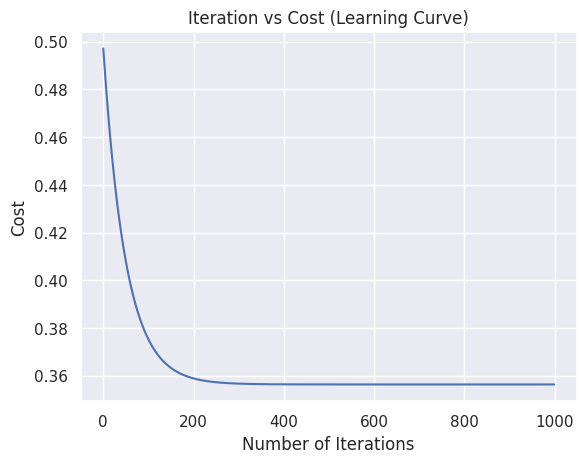

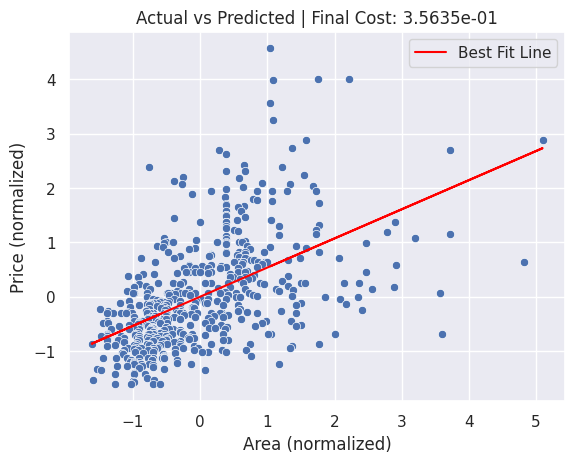


--- Final Learned Parameters ---
w (slope):     0.5360
b (intercept): 0.0000
Final Cost:    3.5635e-01


In [12]:
# Load the dataset using Pandas.
df_house = pd.read_csv('Housing.csv')

# Select one feature (e.g., area) and the target variable (price). And convert them to numpy array
X = np.array(df_house['area'])
y = np.array(df_house['price'])

# Normalize (REQUIRED for large-scale data)
X_mean, X_std = X.mean(), X.std()
y_mean, y_std = y.mean(), y.std()

X = (X - X_mean) / X_std
y = (y - y_mean) / y_std

# Implement the Mean Squared Error (MSE) Cost Function manually.
def calculate_cost(X, y, w, b):
  m = X.shape[0]
  cost = 0.0

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]
    error_squared = error ** 2
    cost = cost + error_squared

  cost = cost / (2 * m)
  return cost


# Calculate the initial cost using random values of slope and intercept.
w = 0.0
b = 0.0

def make_prediction(X, y, w, b):
  m = X.shape[0]
  pred_list = np.zeros((m,))

  for i in range(m):
    pred_list[i] = w * X[i] + b
  return pred_list

predictions = make_prediction(X, y, w = w, b = b)


# Apply Gradient Descent from scratch.
def calculate_gradient(X, y, w, b):
  m = X.shape[0]
  dj_dw = 0.0
  dj_db = 0.0

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]

    dj_dw = dj_dw + (error * X[i])
    dj_db = dj_db + error

  return dj_dw / m, dj_db / m


def gradient_descent(X, y, w_input, b_input, max_iter, alpha = 0.01):
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    cost = calculate_cost(X, y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    if i % 100 == 0:
      print(f'iteration: {i}, Cost: {cost:0.4f}, W: {w:0.4f}, b: {b:0.4f}')

  return w, b, cost_memo, iteration

# Train for 1000 iterations.
w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input = 0, b_input =  0, max_iter = 1000, alpha = 0.01)

# Plot: Iteration vs Cost
plt.plot(iter_list, cost_memo)
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Iteration vs Cost (Learning Curve)")
plt.show()

# Plot: Actual vs Predicted Values
final_pred = make_prediction(X, y, w = w_final, b = b_final)


sns.scatterplot(x = X, y = y)
plt.plot(X, final_pred, color = 'red', label = 'Best Fit Line')
plt.xlabel("Area (normalized)")
plt.ylabel("Price (normalized)")
plt.title(f"Actual vs Predicted | Final Cost: {calculate_cost(X, y, w_final, b_final):0.4e}")
plt.legend()
plt.show()

# Report the final learned parameters.
print(f"\n--- Final Learned Parameters ---")
print(f"w (slope):     {w_final:.4f}")
print(f"b (intercept): {b_final:.4f}")
print(f"Final Cost:    {cost_memo[-1]:.4e}")

# Problem 2: Student Performance Prediction
Dataset:
Student Performance Dataset

Tasks
- Predict math score using reading score. convert them to numpy array from the dataframe
- Implement the MSE Cost Function manually.
- Compute the gradient formulas manually.
- Perform Gradient Descent for 500 iterations.
- Print the cost after every 50 iterations.
- Plot Cost vs Iteration.


Iteration:   0, Cost: 0.4933, w: 0.0082, b: 0.0000
Iteration:  50, Cost: 0.2857, w: 0.3279, b: 0.0000
Iteration: 100, Cost: 0.2097, w: 0.5213, b: 0.0000
Iteration: 150, Cost: 0.1818, w: 0.6383, b: 0.0000
Iteration: 200, Cost: 0.1717, w: 0.7091, b: -0.0000
Iteration: 250, Cost: 0.1679, w: 0.7520, b: -0.0000
Iteration: 300, Cost: 0.1666, w: 0.7779, b: -0.0000
Iteration: 350, Cost: 0.1661, w: 0.7936, b: -0.0000
Iteration: 400, Cost: 0.1659, w: 0.8031, b: -0.0000
Iteration: 450, Cost: 0.1658, w: 0.8088, b: -0.0000


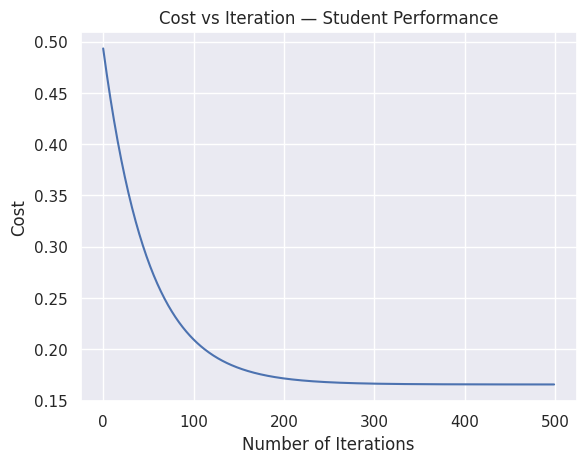

In [18]:
# load dataset
df_student = pd.read_csv('StudentsPerformance.csv')

# Predict math score using reading score. convert them to numpy array from the dataframe
X = np.array(df_student['reading score'])
y = np.array(df_student['math score'])

# normalize
X = (X - X.mean()) / X.std()
y = (y - y.mean()) / y.std()

# Implement the MSE Cost Function manually.
def cost_func(X, y, w, b):
  m = X.shape[0]
  cost = 0.0

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]
    error_squared = error ** 2
    cost = cost + error_squared

  cost = cost / (2 * m)
  return cost

# Compute the gradient formulas manually.
def compute_gradient(X, y, w, b):
    m = X.shape[0]
    dj_dw = 0.0
    dj_db = 0.0

    for i in range(m):
      prediction = w * X[i] + b
      error = prediction - y[i]
      dj_dw = dj_dw + (error * X[i])
      dj_db = dj_db + error

    return dj_dw / m, dj_db / m


def gradient_descent(X, y, w_input, b_input, max_iter, alpha = 0.01):
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    dj_dw, dj_db = compute_gradient(X, y, w, b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    cost = cost_func(X, y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    # Print the cost after every 50 iterations.
    if i % 50 == 0:
      print(f'Iteration: {i:3d}, Cost: {cost:0.4f}, w: {w:0.4f}, b: {b:0.4f}')

  return w, b, cost_memo, iteration


# Perform Gradient Descent for 500 iterations.
w = 0.0
b = 0.0

w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input = 0, b_input = 0, max_iter = 500, alpha = 0.01)

# Plot Cost vs Iteration.
plt.plot(iter_list, cost_memo)
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iteration — Student Performance")
plt.show()

# Problem 3: Insurance Charges Prediction
Dataset:
Medical Cost Personal Dataset

Tasks
- Use age as input feature.
- Use charges as target.
- Convert them to numpy array from the dataframe
- Implement:
  - Cost Function
  - Gradient Calculation
  - Gradient Descent
- Train for 1000 iterations.
- Compare initial and final costs.
- Visualize the regression line.


iteration: 0, Cost: 0.4991, W: 0.0030, b: -0.0000
iteration: 100, Cost: 0.4612, W: 0.1907, b: -0.0000
iteration: 200, Cost: 0.4561, W: 0.2593, b: -0.0000
iteration: 300, Cost: 0.4554, W: 0.2845, b: -0.0000
iteration: 400, Cost: 0.4553, W: 0.2937, b: -0.0000
iteration: 500, Cost: 0.4553, W: 0.2971, b: -0.0000
iteration: 600, Cost: 0.4553, W: 0.2983, b: -0.0000
iteration: 700, Cost: 0.4553, W: 0.2987, b: -0.0000
iteration: 800, Cost: 0.4553, W: 0.2989, b: -0.0000
iteration: 900, Cost: 0.4553, W: 0.2990, b: -0.0000

Initial Cost: 0.5000
Final Cost:   0.4553


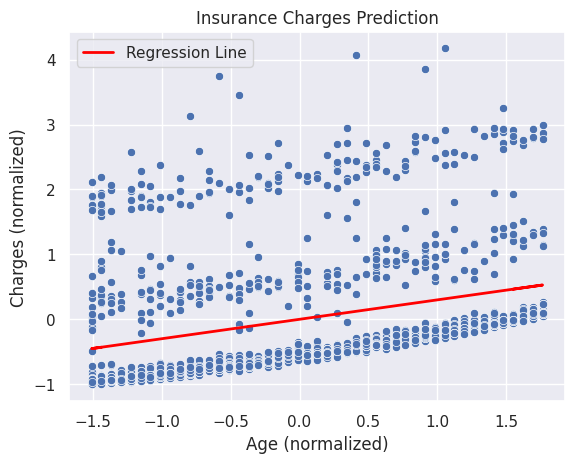

In [22]:
# load dataset
df_insu = pd.read_csv('insurance.csv')

# Use age as input feature. Use charges as target. Convert them to numpy array from the dataframe
X = np.array(df_insu['age'])
y = np.array(df_insu['charges'])

# normalize
X = (X - X.mean()) / X.std()
y = (y - y.mean()) / y.std()

# Implement: Cost Function, Gradient Calculation, Gradient Descent
def cal_cost(X, y, w, b):
  m = X.shape[0]
  cost = 0.0

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]
    error_squared = error ** 2
    cost = cost + error_squared

  cost = cost / (2 * m)
  return cost

def calc_grad(X, y, w, b):
  m = X.shape[0]
  dj_dw = 0.0
  dj_db = 0.0

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]
    dj_dw = dj_dw + (error * X[i])
    dj_db = dj_db + error

  return dj_dw / m, dj_db / m

def grad_desc(X, y, w_input, b_input, max_iter, alpha = 0.01):
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    dj_dw, dj_db = calc_grad(X, y, w, b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    cost = cal_cost(X, y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    if i % 100 == 0:
      print(f'iteration: {i}, Cost: {cost:0.4f}, W: {w:0.4f}, b: {b:0.4f}')

  return w, b, cost_memo, iteration

# Train for 1000 iterations.
w_final, b_final, cost_memo, iter_list = grad_desc(X, y, w_input = 0, b_input = 0, max_iter = 1000, alpha = 0.01)

# Compare initial and final costs.
initial_cost = cal_cost(X, y, 0, 0)
final_cost = cost_memo[-1]
print(f'\nInitial Cost: {initial_cost:.4f}')
print(f'Final Cost:   {final_cost:.4f}')

# Visualize the regression line.
y_pred = w_final * X + b_final

sns.scatterplot(x = X, y = y)
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Age (normalized)')
plt.ylabel('Charges (normalized)')
plt.title('Insurance Charges Prediction')
plt.legend()
plt.show()

# Problem 4: Salary Prediction
Dataset:
Salary Dataset

Tasks
- Predict Salary from YearsExperience.
- Initialize parameters randomly.
- Calculate cost before training.
- Apply Gradient Descent.
- Plot:
  - Cost vs Iteration
  - Regression Line


Initial Cost: 0.1470

iteration: 0, Cost: 0.1445, W: 0.5015, b: -0.1369
iteration: 50, Cost: 0.0665, W: 0.6898, b: -0.0828
iteration: 100, Cost: 0.0380, W: 0.8037, b: -0.0501
iteration: 150, Cost: 0.0276, W: 0.8727, b: -0.0303
iteration: 200, Cost: 0.0237, W: 0.9144, b: -0.0183
iteration: 250, Cost: 0.0223, W: 0.9396, b: -0.0111
iteration: 300, Cost: 0.0218, W: 0.9549, b: -0.0067
iteration: 350, Cost: 0.0216, W: 0.9641, b: -0.0041
iteration: 400, Cost: 0.0216, W: 0.9697, b: -0.0025
iteration: 450, Cost: 0.0215, W: 0.9731, b: -0.0015
iteration: 500, Cost: 0.0215, W: 0.9751, b: -0.0009
iteration: 550, Cost: 0.0215, W: 0.9763, b: -0.0005
iteration: 600, Cost: 0.0215, W: 0.9771, b: -0.0003
iteration: 650, Cost: 0.0215, W: 0.9775, b: -0.0002
iteration: 700, Cost: 0.0215, W: 0.9778, b: -0.0001
iteration: 750, Cost: 0.0215, W: 0.9780, b: -0.0001
iteration: 800, Cost: 0.0215, W: 0.9781, b: -0.0000
iteration: 850, Cost: 0.0215, W: 0.9781, b: -0.0000
iteration: 900, Cost: 0.0215, W: 0.9782, b: -

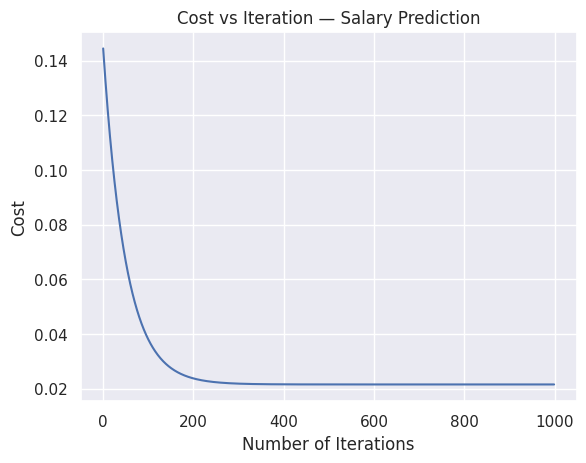

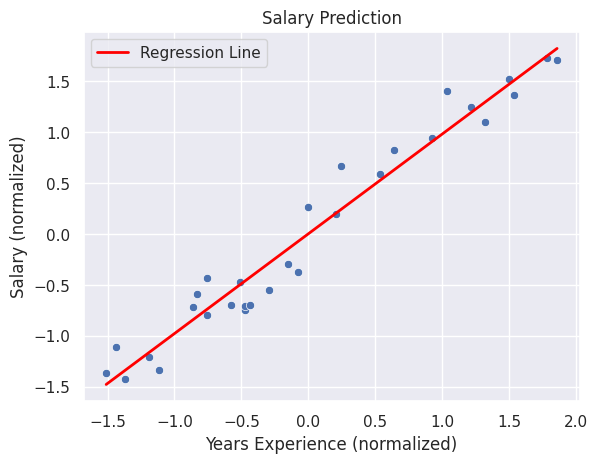

In [25]:
# load data
df_sal = pd.read_csv('Salary_Data.csv')

# Predict Salary from YearsExperience.
X = np.array(df_sal['YearsExperience'])
y = np.array(df_sal['Salary'])

# Normalize
X = (X - X.mean()) / X.std()
y = (y - y.mean()) / y.std()

# Initialize parameters randomly.
np.random.seed(42)

w = np.random.randn()
b = np.random.randn()

def cal_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        cost = cost + error ** 2
    cost = cost / (2 * m)
    return cost

# Gradient Descent.
def calc_grad(X, y, w, b):
    m = X.shape[0]
    dj_dw = 0.0
    dj_db = 0.0
    for i in range(m):
        error = (w * X[i] + b) - y[i]
        dj_dw = dj_dw + (error * X[i])
        dj_db = dj_db + error
    return dj_dw / m, dj_db / m


def grad_des(X, y, w_input, b_input, max_iter, alpha = 0.01):
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    dj_dw, dj_db = calc_grad(X, y, w, b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    cost = cal_cost(X, y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    if i % 50 == 0:
      print(f'iteration: {i}, Cost: {cost:0.4f}, W: {w:0.4f}, b: {b:0.4f}')

  return w, b, cost_memo, iteration


# Calculate cost before training.
initial_cost = cal_cost(X, y, w, b)
print(f'Initial Cost: {initial_cost:.4f}\n')

# Apply Gradient Descent.
w_final, b_final, cost_memo, iter_list = grad_des(X, y, w_input=w, b_input=b, max_iter=1000, alpha=0.01)
print(f'\nFinal Cost: {cost_memo[-1]:.4f}')

# Plot: Cost vs Iteration
plt.plot(iter_list, cost_memo)
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.title('Cost vs Iteration — Salary Prediction')
plt.show()

# Plot: Regression Line
y_pred = w_final * X + b_final

sns.scatterplot(x=X, y=y)
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Years Experience (normalized)')
plt.ylabel('Salary (normalized)')
plt.title('Salary Prediction')
plt.legend()
plt.show()

# Problem 5: Car Fuel Consumption Prediction
Dataset:
Auto MPG Dataset

Tasks
- Use horsepower to predict mpg.
- Implement MSE Cost Function manually.
- Apply Gradient Descent.
- Train for different learning rates:
  - 0.001
  - 0.01
  - 0.1
- Compare the convergence for different learning rates.


[alpha=0.001] Iteration:    0, Cost: 0.4994, w: -0.0008, b: -0.0000
[alpha=0.001] Iteration:  100, Cost: 0.4446, w: -0.0748, b: 0.0000
[alpha=0.001] Iteration:  200, Cost: 0.3997, w: -0.1418, b: 0.0000
[alpha=0.001] Iteration:  300, Cost: 0.3629, w: -0.2024, b: 0.0000
[alpha=0.001] Iteration:  400, Cost: 0.3328, w: -0.2573, b: 0.0000
[alpha=0.001] Iteration:  500, Cost: 0.3082, w: -0.3069, b: 0.0000
[alpha=0.001] Iteration:  600, Cost: 0.2880, w: -0.3518, b: 0.0000
[alpha=0.001] Iteration:  700, Cost: 0.2715, w: -0.3924, b: 0.0000
[alpha=0.001] Iteration:  800, Cost: 0.2580, w: -0.4291, b: 0.0000
[alpha=0.001] Iteration:  900, Cost: 0.2470, w: -0.4624, b: 0.0000
Final Cost: 0.2380
[alpha=0.01] Iteration:    0, Cost: 0.4940, w: -0.0078, b: -0.0000
[alpha=0.01] Iteration:  100, Cost: 0.2368, w: -0.4963, b: 0.0000
[alpha=0.01] Iteration:  200, Cost: 0.2024, w: -0.6752, b: 0.0000
[alpha=0.01] Iteration:  300, Cost: 0.1977, w: -0.7406, b: 0.0000
[alpha=0.01] Iteration:  400, Cost: 0.1971, w

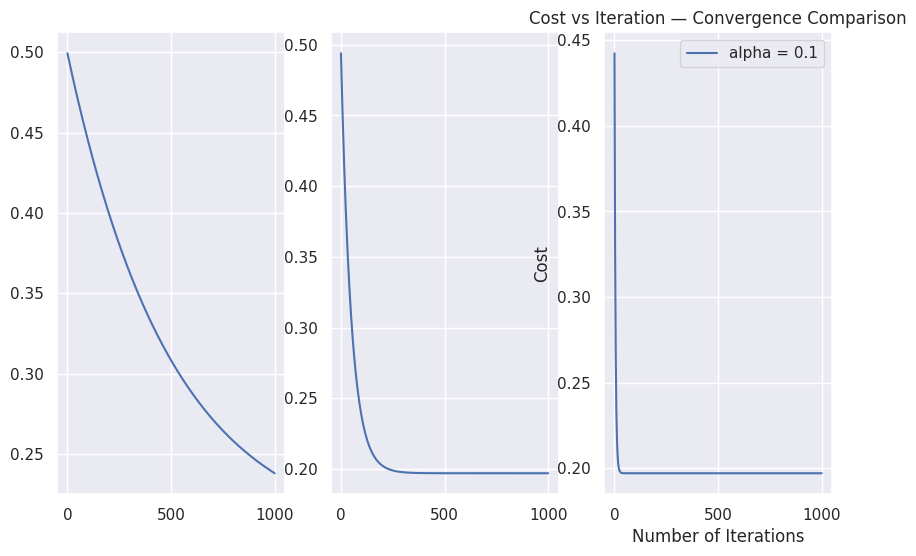

In [45]:
# fetch dataset
auto_mpg = fetch_ucirepo(id=9)

# data (as pandas dataframes)
# Use horsepower to predict mpg.
X = np.array(auto_mpg.data.features['horsepower'])
y = np.array(auto_mpg.data.targets['mpg'])

# Drop NaN values (horsepower has missing values in this dataset)
mask = ~np.isnan(X) & ~np.isnan(y)
X = X[mask]
y = y[mask]

# Normalize
X = (X - X.mean()) / X.std()
y = (y - y.mean()) / y.std()

# Implement MSE Cost Function manually.
def cal_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        cost = cost + error ** 2
    return cost / (2 * m)

# Gradient
def calc_grad(X, y, w, b):
    m = X.shape[0]
    dj_dw = 0.0
    dj_db = 0.0
    for i in range(m):
        error = (w * X[i] + b) - y[i]
        dj_dw = dj_dw + (error * X[i])
        dj_db = dj_db + error
    return dj_dw / m, dj_db / m

def grad_desc(X, y, w_input, b_input, max_iter, alpha=0.01):
    w = w_input
    b = b_input
    cost_memo = []
    iteration = []

    for i in range(max_iter):
        dj_dw, dj_db = calc_grad(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = cal_cost(X, y, w, b)
        cost_memo.append(cost)
        iteration.append(i)

        if i % 100 == 0:
            print(f'[alpha={alpha}] Iteration: {i:4d}, Cost: {cost:0.4f}, w: {w:0.4f}, b: {b:0.4f}')

    return w, b, cost_memo, iteration

# Train for different learning rates: 0.001, 0.01, 0.1
# for 0.001
w1, b1, cost_memo1, iter_list1 = grad_desc(X, y, w_input=0, b_input=0, max_iter=1000, alpha=0.001)
print(f'Final Cost: {cost_memo1[-1]:.4f}')

# for 0.01
w2, b2, cost_memo2, iter_list2 = grad_desc(X, y, w_input=0, b_input=0, max_iter=1000, alpha=0.01)
print(f'Final Cost: {cost_memo2[-1]:.4f}')

# for 0.1
w3, b3, cost_memo3, iter_list3 = grad_desc(X, y, w_input=0, b_input=0, max_iter=1000, alpha=0.1)
print(f'Final Cost: {cost_memo3[-1]:.4f}')

fig, axes = plt.subplots(1, 3, figsize = (10, 6))

axes[0].plot(iter_list1, cost_memo1, label='alpha = 0.001')
axes[1].plot(iter_list2, cost_memo2, label='alpha = 0.01')
axes[2].plot(iter_list3, cost_memo3, label='alpha = 0.1')
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.title('Cost vs Iteration — Convergence Comparison')
plt.legend()
plt.show()